In [7]:
import pandas as pd
import numpy as np
import zipfile

In [2]:
# Load the .npz file
traj = np.load('/home/dataopske/Desktop/jav/data/raw/worldmove/worldmove_trajectories.npz', allow_pickle=True)
# wards_full_gdf = pd.read_csv('/home/dataopske/Desktop/jav/data/processed/wards_full_gdf(with_spatial_temporal_gini).csv')
# See what's inside (keys like 'lon', 'lat', 'time', 'agent_id', etc.)
print("Keys in the file:", traj.files)

# Example: Print shapes of arrays (adjust keys based on output)
for key in traj.files:
    print(f"{key}: shape={traj[key].shape}, dtype={traj[key].dtype}")

Keys in the file: ['grid', 'poi', 'pop', 'traj']
grid: shape=(), dtype=object
poi: shape=(30, 48, 34), dtype=float32
pop: shape=(30, 48), dtype=float64
traj: shape=(104538, 48), dtype=int64


In [8]:
# Open the ZIP file in read mode ('r')
zip_path = '/home/dataopske/Desktop/jav/data/raw/kenyawards/kenya_wards.zip'  # Replace with your ZIP file path
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    file_list = zip_ref.namelist()  # Returns a list of file paths (including subdirs)
    print(file_list)  # e.g., ['data.csv', 'folder/image.jpg']
    pass

['Kenya_Wards/', 'Kenya_Wards/kenya_wards.cpg', 'Kenya_Wards/kenya_wards.dbf', 'Kenya_Wards/kenya_wards.prj', 'Kenya_Wards/kenya_wards.qpj', 'Kenya_Wards/kenya_wards.shp', 'Kenya_Wards/kenya_wards.shx']


The zip contains multiple files, we're interested in the `Kenya_Wards/kenya_wards.shp`

In [9]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from scipy.spatial.distance import cdist

# Load data
traj = np.load('/home/dataopske/Desktop/jav/data/raw/worldmove/worldmove_trajectories.npz', allow_pickle=True)
ward_full_gdf = gpd.read_file(f"zip://{zip_path}!Kenya_Wards/kenya_wards.shp")


grid_dict = traj['grid'].item()
poi_data = traj['poi']      # (30, 48, 34) - 30 cells, 48 timesteps, 34 POI types
pop_data = traj['pop']       # (30, 48) - 30 cells, 48 timesteps
traj_data = traj['traj']     # (104538, 48) - 104,538 agents, 48 timesteps

print(f"Total grid cells in dict: {len(grid_dict)}")  # Should be 1440
print(f"Agents tracked: {traj_data.shape[0]}")
print(f"Timesteps: {traj_data.shape[1]}")

Total grid cells in dict: 1440
Agents tracked: 104538
Timesteps: 48


In [10]:
# Extract cell centroids from grid dictionary
cell_ids = []
cell_coords = []

for cell_id_str, coords in grid_dict.items():
    cell_ids.append(int(cell_id_str))
    cell_coords.append(coords)  # [lon, lat]

cell_coords = np.array(cell_coords)

# Create GeoDataFrame of grid cells
grid_gdf = gpd.GeoDataFrame(
    {'cell_id': cell_ids},
    geometry=[Point(lon, lat) for lon, lat in cell_coords],
    crs='EPSG:4326'
)

# Transform to match ward CRS (EPSG:32737)
grid_gdf = grid_gdf.to_crs('EPSG:32737')

print(f"Grid cells created: {len(grid_gdf)}")
grid_gdf.head()

Grid cells created: 1440


,cell_id,geometry
0,0,POINT (240575.158 9871043.776)
1,1,POINT (241316.295 9870796.395)
2,2,POINT (242856.284 9871107.748)
3,3,POINT (243795.629 9870820.386)
4,4,POINT (245160.049 9871506.409)


In [16]:
grid_gdf = grid_gdf.to_crs(ward_full_gdf.crs)

cell_to_ward = gpd.sjoin(
    grid_gdf,
    ward_full_gdf[['ward', 'geometry']],
    how='left',
    predicate='within'
)

# Drop cells outside Nairobi
cell_to_ward = cell_to_ward.dropna(subset=['ward'])

print(f"Cells mapped to wards: {cell_to_ward['ward'].notna().sum()} / {len(cell_to_ward)}")


Cells mapped to wards: 1440 / 1440


In [17]:
# Check if 48 timesteps = 48 half-hours (30-min intervals)
# Pop at t=0 vs t=1 shows significant change, suggesting different times of day

# Assumption: 48 timesteps = 30-minute intervals (24 hours × 2)
# Timestep 0 = 00:00, Timestep 1 = 00:30, ..., Timestep 12 = 06:00, etc.

timestep_to_hour = {
    t: (t // 2) for t in range(48)
}

# Map our target hours to timesteps
target_hours = [6, 9, 15]
target_timesteps = {
    6: [12, 13],   # 06:00 and 06:30
    9: [18, 19],   # 09:00 and 09:30
    15: [30, 31]   # 15:00 and 15:30
}

print("Hour to Timestep mapping:")
for hour, timesteps in target_timesteps.items():
    print(f"  Hour {hour}: timesteps {timesteps}")

Hour to Timestep mapping:
  Hour 6: timesteps [12, 13]
  Hour 9: timesteps [18, 19]
  Hour 15: timesteps [30, 31]


In [18]:
# Process trajectory data to extract trips
# Each row is an agent, each column is the cell they're in at that timestep

print("Processing trajectories...")
trips_list = []

# Only process agents that visit cells inside Nairobi wards
valid_cells = set(cell_to_ward['cell_id'].unique())

for agent_id in range(traj_data.shape[0]):
    if agent_id % 10000 == 0:
        print(f"  Processing agent {agent_id}/{traj_data.shape[0]}")
    
    agent_trajectory = traj_data[agent_id, :]
    
    for t in range(len(agent_trajectory) - 1):
        origin_cell = agent_trajectory[t]
        dest_cell = agent_trajectory[t + 1]
        
        # Skip if agent didn't move
        if origin_cell == dest_cell:
            continue
        
        # Skip if cells are outside Nairobi
        if origin_cell not in valid_cells or dest_cell not in valid_cells:
            continue
        
        # Get wards
        origin_ward = cell_to_ward.loc[cell_to_ward['cell_id'] == origin_cell, 'ward'].values
        dest_ward = cell_to_ward.loc[cell_to_ward['cell_id'] == dest_cell, 'ward'].values
        
        if len(origin_ward) == 0 or len(dest_ward) == 0:
            continue
        
        hour = timestep_to_hour[t]
        
        trips_list.append({
            'agent_id': agent_id,
            'timestep': t,
            'hour': hour,
            'origin_ward': origin_ward[0],
            'dest_ward': dest_ward[0],
            'origin_cell': origin_cell,
            'dest_cell': dest_cell
        })

trips_df = pd.DataFrame(trips_list)
print(f"\nTotal trips extracted: {len(trips_df):,}")
print(f"Unique agents: {trips_df['agent_id'].nunique():,}")
print(f"Hours covered: {sorted(trips_df['hour'].unique())}")

trips_df.head(10)

Processing trajectories...
  Processing agent 0/104538
  Processing agent 10000/104538
  Processing agent 20000/104538
  Processing agent 30000/104538
  Processing agent 40000/104538
  Processing agent 50000/104538
  Processing agent 60000/104538
  Processing agent 70000/104538
  Processing agent 80000/104538
  Processing agent 90000/104538
  Processing agent 100000/104538

Total trips extracted: 1,439,368
Unique agents: 93,603
Hours covered: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


,agent_id,timestep,hour,origin_ward,dest_ward,origin_cell,dest_cell
0,0,25,12,Roysambu Ward,Zimmerman Ward,265,266
1,0,28,14,Zimmerman Ward,Roysambu Ward,266,265
2,0,32,16,Roysambu Ward,Zimmerman Ward,265,217
3,0,36,18,Zimmerman Ward,Kiambu Township Ward,217,169
4,1,20,10,Utalii Ward,Babandogo,455,454
5,1,22,11,Babandogo,Roysambu Ward,454,453
6,1,23,11,Roysambu Ward,Roysambu Ward,453,405
7,1,31,15,Roysambu Ward,Roysambu Ward,405,404
8,1,32,16,Roysambu Ward,Roysambu Ward,404,452
9,1,37,18,Roysambu Ward,Karura Ward,452,451


In [19]:
# Get cell coordinates in UTM (EPSG:32737) for distance calculation
cell_coords_utm = np.array([[pt.x, pt.y] for pt in grid_gdf.set_index('cell_id').loc[trips_df['origin_cell'].unique()].geometry])

# Create lookup for cell coordinates
cell_coord_lookup = dict(zip(
    grid_gdf['cell_id'],
    [(pt.x, pt.y) for pt in grid_gdf.geometry]
))

# Calculate distance and speed for each trip
def calc_distance(row):
    origin = cell_coord_lookup.get(row['origin_cell'])
    dest = cell_coord_lookup.get(row['dest_cell'])
    
    if origin is None or dest is None:
        return np.nan
    
    # Euclidean distance in meters
    return np.sqrt((origin[0] - dest[0])**2 + (origin[1] - dest[1])**2)

trips_df['distance_m'] = trips_df.apply(calc_distance, axis=1)

# Duration = 30 minutes = 0.5 hours (1 timestep)
trips_df['duration_h'] = 0.5

# Speed in km/h
trips_df['speed_kmh'] = (trips_df['distance_m'] / 1000) / trips_df['duration_h']

# Filter unrealistic speeds (cap at 80 km/h for urban traffic)
trips_df = trips_df[trips_df['speed_kmh'] <= 80].copy()

print(f"Average speed: {trips_df['speed_kmh'].mean():.1f} km/h")
print(f"Speed distribution:\n{trips_df['speed_kmh'].describe()}")

Average speed: 0.0 km/h
Speed distribution:
count    1.439368e+06
mean     4.523901e-05
std      8.664600e-05
min      1.378229e-06
25%      1.538495e-05
50%      2.047950e-05
75%      2.712079e-05
max      9.219994e-04
Name: speed_kmh, dtype: float64


In [20]:
# Filter to our target hours
trips_filtered = trips_df[trips_df['hour'].isin(target_hours)].copy()

print(f"Trips in hours {target_hours}: {len(trips_filtered):,}")

# Outgoing trips per ward-hour
outgoing = trips_filtered.groupby(['origin_ward', 'hour']).agg(
    outgoing_trips=('agent_id', 'count'),
    unique_agents=('agent_id', 'nunique'),
    destination_diversity=('dest_ward', 'nunique'),
    avg_speed=('speed_kmh', 'mean')
).reset_index()
outgoing.rename(columns={'origin_ward': 'ward'}, inplace=True)

# Incoming trips per ward-hour
incoming = trips_filtered.groupby(['dest_ward', 'hour']).agg(
    incoming_trips=('agent_id', 'count')
).reset_index()
incoming.rename(columns={'dest_ward': 'ward'}, inplace=True)

# Merge
ward_hour_mobility = outgoing.merge(incoming, on=['ward', 'hour'], how='outer')
ward_hour_mobility = ward_hour_mobility.fillna(0)

print(f"Ward-hour mobility rows: {len(ward_hour_mobility)}")
ward_hour_mobility.head(10)

Trips in hours [6, 9, 15]: 206,444
Ward-hour mobility rows: 333


,ward,hour,outgoing_trips,unique_agents,destination_diversity,avg_speed,incoming_trips
0,Airbase Ward,6,793.0,760.0,50.0,0.000030,836
1,Airbase Ward,9,1319.0,1241.0,72.0,0.000033,1282
2,Airbase Ward,15,1091.0,1040.0,72.0,0.000033,1078
3,Athi River Ward,6,5.0,4.0,4.0,0.000017,5
4,Athi River Ward,9,4.0,4.0,2.0,0.000111,7
5,Athi River Ward,15,7.0,7.0,4.0,0.000148,8
6,Babandogo,6,699.0,698.0,55.0,0.000034,672
7,Babandogo,9,1123.0,1122.0,55.0,0.000033,1076
8,Babandogo,15,908.0,908.0,54.0,0.000033,848
9,Biashara Ward,6,60.0,55.0,13.0,0.000093,48


In [21]:
# pop_data has shape (30, 48) but only for a SUBSET of cells
# Need to map these 30 cells to the full 1440 grid

# The 30 cells in pop_data/poi_data are likely the cells with highest activity
# We need to identify which cells they correspond to

# Let's check which cells have agents at t=0
cells_with_agents_t0 = np.unique(traj_data[:, 0])
print(f"Cells with agents at t=0: {len(cells_with_agents_t0)}")

# Hypothesis: The 30 cells in pop_data are the most active cells
# Map based on cell activity
cell_activity = pd.DataFrame(traj_data).apply(pd.Series.value_counts).sum(axis=1).sort_values(ascending=False)
top_30_cells = cell_activity.head(30).index.tolist()

print(f"Top 30 most active cells: {top_30_cells}")

# Create mapping: pop_data row index -> actual cell_id
pop_cell_mapping = {i: cell_id for i, cell_id in enumerate(top_30_cells)}

# Extract population for each ward-hour
ward_hour_population = []

for hour in target_hours:
    # Average timesteps for this hour (e.g., hour 6 = timesteps 12, 13)
    timesteps = target_timesteps[hour]
    
    for ward in cell_to_ward['ward'].unique():
        # Get cells in this ward
        ward_cells = cell_to_ward[cell_to_ward['ward'] == ward]['cell_id'].values
        
        # Check which of the top 30 cells are in this ward
        active_pop = 0
        for pop_idx, cell_id in pop_cell_mapping.items():
            if cell_id in ward_cells:
                # Average population across timesteps for this hour
                active_pop += pop_data[pop_idx, timesteps].mean()
        
        ward_hour_population.append({
            'ward': ward,
            'hour': hour,
            'active_population': active_pop
        })

pop_df = pd.DataFrame(ward_hour_population)

print("Population presence sample:")
print(pop_df.head(10))

Cells with agents at t=0: 1123
Top 30 most active cells: [456, 504, 455, 548, 502, 503, 408, 781, 648, 549, 555, 410, 457, 501, 840, 596, 600, 454, 556, 644, 409, 829, 550, 551, 585, 650, 597, 830, 599, 407]
Population presence sample:
                   ward  hour  active_population
0    Ngecha Tigoni Ward     6                0.0
1           Cianda Ward     6                0.0
2           Karuri Ward     6                0.0
3         Ndumberi Ward     6                0.0
4           Riabai Ward     6                0.0
5  Kiambu Township Ward     6                0.0
6       Ting'ang'a Ward     6                0.0
7           Kahawa West     6                0.0
8              Gitothua     6                0.0
9         Biashara Ward     6                0.0


In [25]:

pop_df.describe()

,hour,active_population
count,333.000000,333.000000
mean,10.000000,3959.286763
std,3.747288,15885.357981
min,6.000000,0.000000
25%,6.000000,0.000000
50%,9.000000,0.000000
75%,15.000000,0.000000
max,15.000000,177434.968750


In [26]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import numpy as np

# Load your existing ward temporal data
ward_csv_path = '/home/dataopske/Desktop/jav/data/processed/spatio_temporal_calendar.csv'
ward_temporal_base = pd.read_csv(ward_csv_path)

# Convert geometry from WKT string to shapely geometry
ward_temporal_base['geometry'] = ward_temporal_base['geometry'].apply(wkt.loads)
ward_temporal_base = gpd.GeoDataFrame(ward_temporal_base, geometry='geometry', crs="EPSG:32737")

print(f"Existing ward temporal data shape: {ward_temporal_base.shape}")
print(f"Unique wards: {ward_temporal_base['ward'].nunique()}")
print(f"Unique hours: {sorted(ward_temporal_base['hour'].unique())}")
print(f"Columns: {ward_temporal_base.columns.tolist()}")

Existing ward temporal data shape: (7905, 30)
Unique wards: 85
Unique hours: [np.int64(6), np.int64(9), np.int64(15)]
Columns: ['gid', 'pop2009', 'county', 'subcounty', 'ward', 'uid', 'scuid', 'cuid', 'geometry', 'population', 'constituency', 'poverty_rate', 'intersect_area', 'ward_area', 'coverage_ratio', 'pop_served', 'pct_access', 'coverage_area_km2', 'pop_not_served', 'subcounty_gini', 'hour', 'trips_per_hour', 'service_per_1k_pop', 'service_rank', 'date', 'weekday', 'is_weekend', 'trips_per_hour_adj', 'service_per_1k_pop_adj', 'trips_per_person_per_hour_adj']


In [27]:
# Check and add missing temporal features
if 'hour_sin' not in ward_temporal_base.columns:
    ward_temporal_base['hour_sin'] = np.sin(2 * np.pi * ward_temporal_base['hour'] / 24)
    ward_temporal_base['hour_cos'] = np.cos(2 * np.pi * ward_temporal_base['hour'] / 24)
    print("✓ Added hour_sin, hour_cos")

if 'is_rush_hour' not in ward_temporal_base.columns:
    ward_temporal_base['is_rush_hour'] = ward_temporal_base['hour'].isin([7, 8, 17, 18])
    print("✓ Added is_rush_hour")

# Ensure date column exists (if missing, create dummy dates)
if 'date' not in ward_temporal_base.columns:
    ward_temporal_base['date'] = '2025-10-01'  # Placeholder
    print("✓ Added date column")

ward_temporal_base['date'] = pd.to_datetime(ward_temporal_base['date'])

✓ Added hour_sin, hour_cos
✓ Added is_rush_hour


In [28]:
# Check what we got from WorldMove extraction
print(f"\nWorldMove features shape: {ward_hour_features.shape}")
print(f"Columns: {ward_hour_features.columns.tolist()}")
print(f"Sample:\n{ward_hour_features.head()}")

# Merge on 'ward' and 'hour'
ward_temporal_final = ward_temporal_base.merge(
    ward_hour_features,
    on=['ward', 'hour'],
    how='left',
    suffixes=('', '_worldmove')
)

print(f"\nAfter merge shape: {ward_temporal_final.shape}")
print(f"Rows before merge: {len(ward_temporal_base)}")
print(f"Rows after merge: {len(ward_temporal_final)}")


WorldMove features shape: (333, 8)
Columns: ['ward', 'hour', 'outgoing_trips', 'unique_agents', 'destination_diversity', 'avg_speed', 'incoming_trips', 'active_population']
Sample:
              ward  hour  outgoing_trips  unique_agents  \
0     Airbase Ward     6           793.0          760.0   
1     Airbase Ward     9          1319.0         1241.0   
2     Airbase Ward    15          1091.0         1040.0   
3  Athi River Ward     6             5.0            4.0   
4  Athi River Ward     9             4.0            4.0   

   destination_diversity  avg_speed  incoming_trips  active_population  
0                   50.0   0.000030             836       63778.382477  
1                   72.0   0.000033            1282       38116.495369  
2                   72.0   0.000033            1078        8991.806641  
3                    4.0   0.000017               5           0.000000  
4                    2.0   0.000111               7           0.000000  

After merge shape: (7905

In [34]:
ward_temporal_final

,gid,pop2009,county,subcounty,ward,uid,scuid,cuid,geometry,population,...,trips_per_person_per_hour_adj,hour_sin,hour_cos,is_rush_hour,outgoing_trips,unique_agents,destination_diversity,avg_speed,incoming_trips,active_population
0,2078,43168.0,Nairobi,Kamukunji Sub County,Airbase Ward,t4Suo8Enc7T,qoLIT7y5f5c,jkG3zaihdSs,"POLYGON ((263765.584 9860350.471, 263805.22 98...",105433.255157,...,0.011040,1.000000,6.123234e-17,False,793.0,760.0,50.0,0.000030,836.0,63778.382477
1,2078,43168.0,Nairobi,Kamukunji Sub County,Airbase Ward,t4Suo8Enc7T,qoLIT7y5f5c,jkG3zaihdSs,"POLYGON ((263765.584 9860350.471, 263805.22 98...",105433.255157,...,0.003680,0.707107,-7.071068e-01,False,1319.0,1241.0,72.0,0.000033,1282.0,38116.495369
2,2078,43168.0,Nairobi,Kamukunji Sub County,Airbase Ward,t4Suo8Enc7T,qoLIT7y5f5c,jkG3zaihdSs,"POLYGON ((263765.584 9860350.471, 263805.22 98...",105433.255157,...,0.011040,-0.707107,-7.071068e-01,False,1091.0,1040.0,72.0,0.000033,1078.0,8991.806641
3,2078,43168.0,Nairobi,Kamukunji Sub County,Airbase Ward,t4Suo8Enc7T,qoLIT7y5f5c,jkG3zaihdSs,"POLYGON ((263765.584 9860350.471, 263805.22 98...",105433.255157,...,0.011040,1.000000,6.123234e-17,False,793.0,760.0,50.0,0.000030,836.0,63778.382477
4,2078,43168.0,Nairobi,Kamukunji Sub County,Airbase Ward,t4Suo8Enc7T,qoLIT7y5f5c,jkG3zaihdSs,"POLYGON ((263765.584 9860350.471, 263805.22 98...",105433.255157,...,0.003680,0.707107,-7.071068e-01,False,1319.0,1241.0,72.0,0.000033,1282.0,38116.495369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7900,2083,10488.0,Nairobi,Starehe Sub County,Ziwani/kariokor,nRw6kIlJ23L,nKHlZyN0lt9,jkG3zaihdSs,"POLYGON ((259092.708 9858749.631, 259105.738 9...",55017.339519,...,0.001818,0.707107,-7.071068e-01,False,NaN,NaN,NaN,NaN,NaN,NaN
7901,2083,10488.0,Nairobi,Starehe Sub County,Ziwani/kariokor,nRw6kIlJ23L,nKHlZyN0lt9,jkG3zaihdSs,"POLYGON ((259092.708 9858749.631, 259105.738 9...",55017.339519,...,0.005453,-0.707107,-7.071068e-01,False,NaN,NaN,NaN,NaN,NaN,NaN
7902,2083,10488.0,Nairobi,Starehe Sub County,Ziwani/kariokor,nRw6kIlJ23L,nKHlZyN0lt9,jkG3zaihdSs,"POLYGON ((259092.708 9858749.631, 259105.738 9...",55017.339519,...,0.005453,1.000000,6.123234e-17,False,NaN,NaN,NaN,NaN,NaN,NaN
7903,2083,10488.0,Nairobi,Starehe Sub County,Ziwani/kariokor,nRw6kIlJ23L,nKHlZyN0lt9,jkG3zaihdSs,"POLYGON ((259092.708 9858749.631, 259105.738 9...",55017.339519,...,0.001818,0.707107,-7.071068e-01,False,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

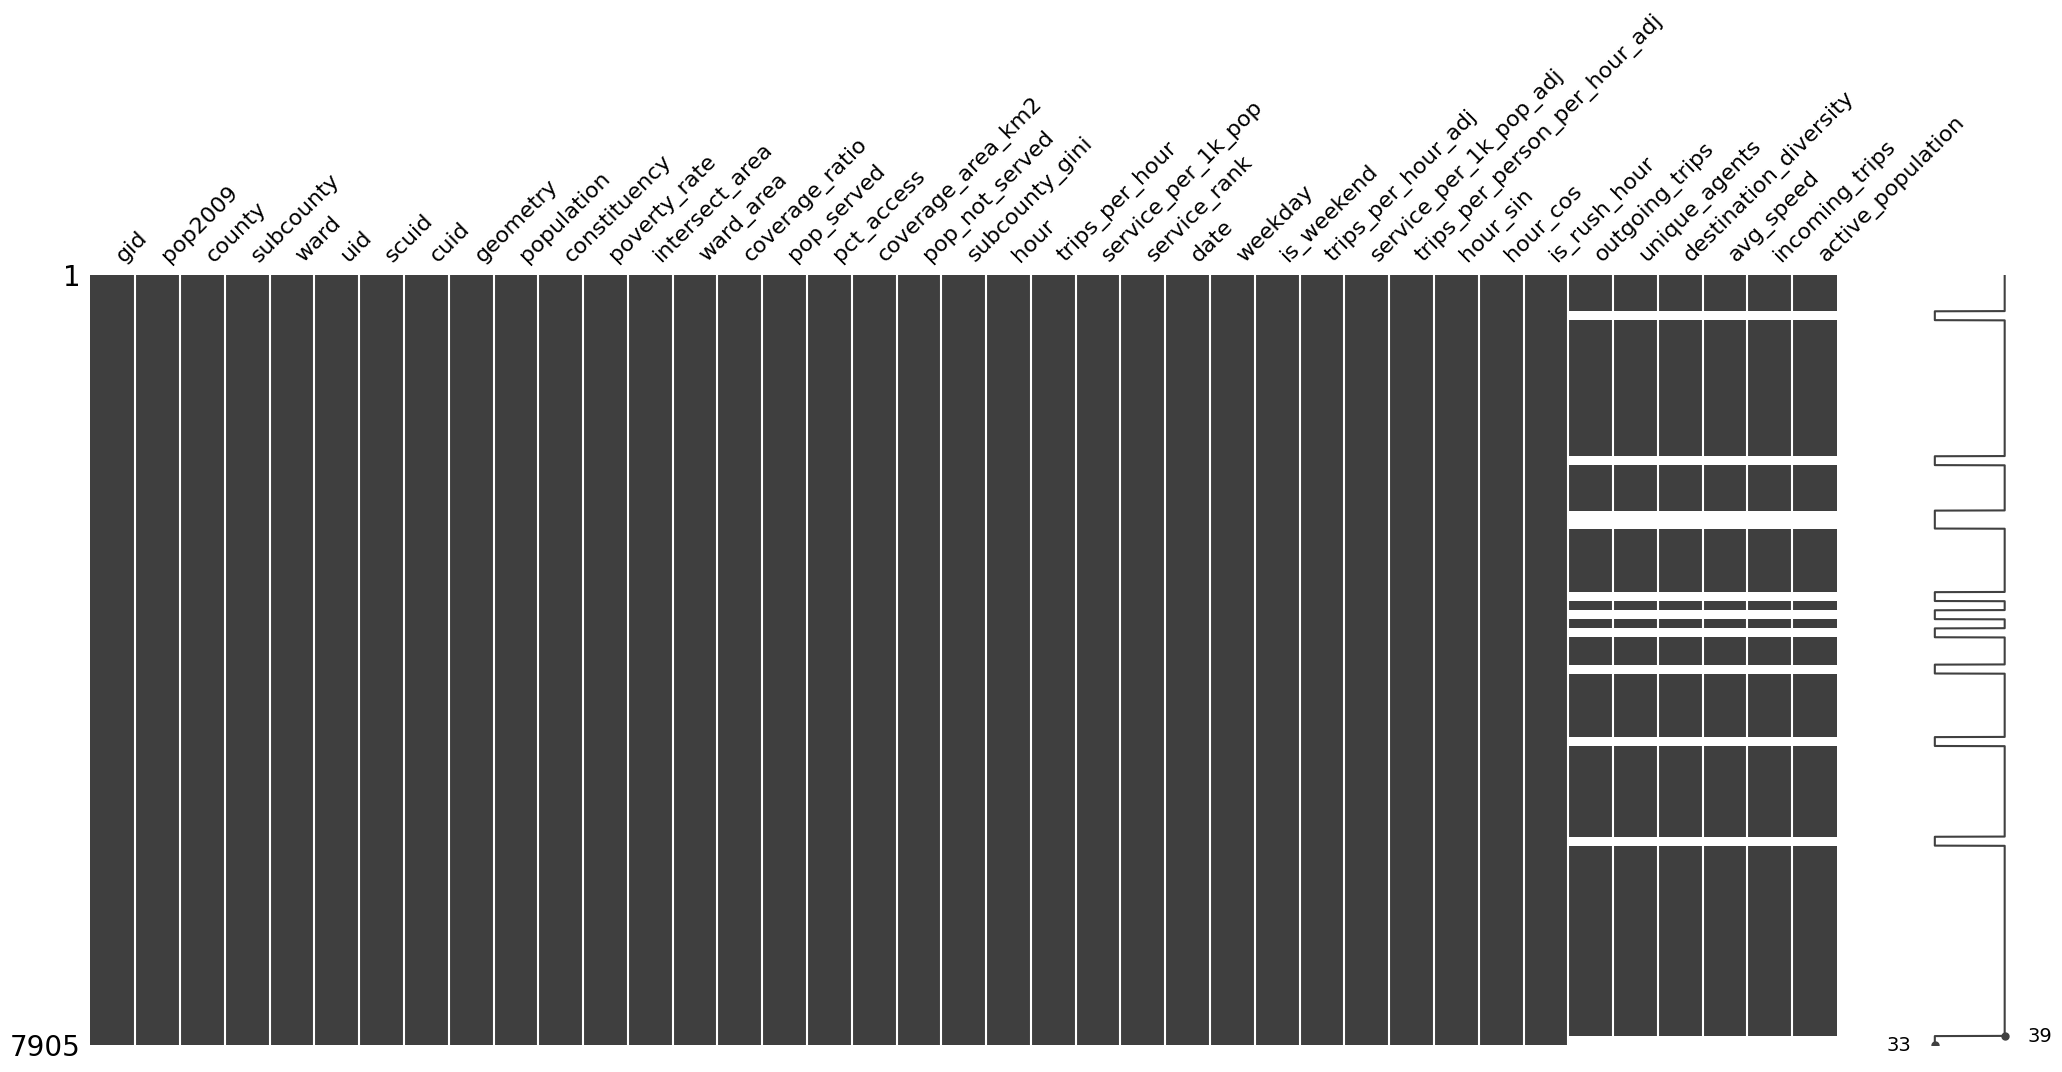

In [33]:
import missingno as msno
msno.matrix(ward_temporal_final)

In [35]:
# Fill missing mobility values with 0 (wards not covered by WorldMove)
mobility_cols = ['outgoing_trips', 'incoming_trips', 'unique_agents', 
                 'destination_diversity', 'avg_speed', 'active_population']

for col in mobility_cols:
    if col in ward_temporal_final.columns:
        before_fill = ward_temporal_final[col].isnull().sum()
        ward_temporal_final[col] = ward_temporal_final[col].fillna(0)
        print(f"Filled {before_fill} missing values in {col}")

print(f"\nMissing values after fill:")
print(ward_temporal_final[mobility_cols].isnull().sum())

Filled 1023 missing values in outgoing_trips
Filled 1023 missing values in incoming_trips
Filled 1023 missing values in unique_agents
Filled 1023 missing values in destination_diversity
Filled 1023 missing values in avg_speed
Filled 1023 missing values in active_population

Missing values after fill:
outgoing_trips           0
incoming_trips           0
unique_agents            0
destination_diversity    0
avg_speed                0
active_population        0
dtype: int64


In [36]:
# 1. Trip density (trips per km²)
ward_temporal_final['area_km2'] = ward_temporal_final.geometry.area / 1e6

ward_temporal_final['trip_density'] = ward_temporal_final.apply(
    lambda row: row['outgoing_trips'] / row['area_km2'] if row['area_km2'] > 0 else 0,
    axis=1
)

# 2. Demand-supply ratio
ward_temporal_final['demand_supply_ratio'] = ward_temporal_final.apply(
    lambda row: row['outgoing_trips'] / row['trips_per_hour'] if row['trips_per_hour'] > 0 else 0,
    axis=1
)

# 3. Activity ratio (active vs resident population)
ward_temporal_final['density_ratio'] = ward_temporal_final.apply(
    lambda row: row['active_population'] / row['population'] if row['population'] > 0 else 0,
    axis=1
)

# Replace inf values with 0
ward_temporal_final = ward_temporal_final.replace([np.inf, -np.inf], 0)

print("✓ Derived metrics calculated")

# Show summary stats
print(f"\nDerived Metrics Summary:")
for col in ['trip_density', 'demand_supply_ratio', 'density_ratio', 'avg_speed']:
    if col in ward_temporal_final.columns:
        stats = ward_temporal_final[ward_temporal_final[col] > 0][col].describe()
        print(f"\n{col}:")
        print(f"  Count non-zero: {(ward_temporal_final[col] > 0).sum()}")
        print(f"  Mean: {stats['mean']:.2f}")
        print(f"  Std: {stats['std']:.2f}")
        print(f"  Min: {stats['min']:.2f}")
        print(f"  Max: {stats['max']:.2f}")

✓ Derived metrics calculated

Derived Metrics Summary:

trip_density:
  Count non-zero: 6882
  Mean: 314.90
  Std: 301.13
  Min: 6.98
  Max: 1747.40

demand_supply_ratio:
  Count non-zero: 6510
  Mean: 4.04
  Std: 11.50
  Min: 0.06
  Max: 147.00

density_ratio:
  Count non-zero: 2139
  Mean: 0.22
  Std: 0.33
  Min: 0.00
  Max: 2.19

avg_speed:
  Count non-zero: 6882
  Mean: 0.00
  Std: 0.00
  Min: 0.00
  Max: 0.00


In [37]:
# Check coverage
print("\n" + "="*60)
print("QUALITY CHECK")
print("="*60)

total_wards = ward_temporal_final['ward'].nunique()
wards_with_mobility = ward_temporal_final[
    ward_temporal_final['outgoing_trips'] > 0
]['ward'].nunique()

print(f"Total wards: {total_wards}")
print(f"Wards with mobility data: {wards_with_mobility}")
print(f"Coverage: {wards_with_mobility / total_wards * 100:.1f}%")

# Check speed distribution
speed_data = ward_temporal_final[ward_temporal_final['avg_speed'] > 0]['avg_speed']
print(f"\nSpeed statistics (km/h):")
print(f"  Observations: {len(speed_data)}")
print(f"  Mean: {speed_data.mean():.1f} km/h")
print(f"  Median: {speed_data.median():.1f} km/h")
print(f"  Std: {speed_data.std():.1f} km/h")

# Sample one ward across hours
sample_ward = ward_temporal_final[ward_temporal_final['outgoing_trips'] > 0]['ward'].iloc[0]
print(f"\nSample ward: {sample_ward}")
sample_df = ward_temporal_final[ward_temporal_final['ward'] == sample_ward][
    ['ward', 'hour', 'trips_per_hour', 'outgoing_trips', 'avg_speed', 'demand_supply_ratio']
].sort_values('hour')
print(sample_df)


QUALITY CHECK
Total wards: 85
Wards with mobility data: 74
Coverage: 87.1%

Speed statistics (km/h):
  Observations: 6882
  Mean: 0.0 km/h
  Median: 0.0 km/h
  Std: 0.0 km/h

Sample ward: Airbase Ward
            ward  hour  trips_per_hour  outgoing_trips  avg_speed  \
0   Airbase Ward     6          1164.0           793.0   0.000030   
3   Airbase Ward     6          1164.0           793.0   0.000030   
6   Airbase Ward     6          1164.0           793.0   0.000030   
9   Airbase Ward     6          1164.0           793.0   0.000030   
12  Airbase Ward     6          1164.0           793.0   0.000030   
..           ...   ...             ...             ...        ...   
86  Airbase Ward    15          1164.0          1091.0   0.000033   
83  Airbase Ward    15          1164.0          1091.0   0.000033   
80  Airbase Ward    15          1164.0          1091.0   0.000033   
89  Airbase Ward    15          1164.0          1091.0   0.000033   
92  Airbase Ward    15          1164.0 

In [38]:
# Define final feature set for LSTM
final_columns = [
    # Identifiers
    'ward', 'hour', 'date', 'weekday', 'is_weekend',
    
    # Spatial
    'geometry', 'population', 'area_km2',
    
    # Transit supply (from GTFS)
    'trips_per_hour', 'service_per_1k_pop',
    
    # Mobility demand (from WorldMove)
    'outgoing_trips', 'incoming_trips', 'unique_agents',
    'destination_diversity', 'avg_speed', 'active_population',
    
    # Derived features
    'trip_density', 'demand_supply_ratio', 'density_ratio',
    
    # Temporal encodings
    'hour_sin', 'hour_cos', 'is_rush_hour'
]

# Keep only columns that exist
existing_columns = [col for col in final_columns if col in ward_temporal_final.columns]
missing_columns = [col for col in final_columns if col not in ward_temporal_final.columns]

if missing_columns:
    print(f"\n⚠️  Missing columns: {missing_columns}")

ward_temporal_final_clean = ward_temporal_final[existing_columns].copy()

print(f"\n✅ Final dataset shape: {ward_temporal_final_clean.shape}")
print(f"Features: {len(existing_columns)}")
print(f"Columns:\n{existing_columns}")


✅ Final dataset shape: (7905, 22)
Features: 22
Columns:
['ward', 'hour', 'date', 'weekday', 'is_weekend', 'geometry', 'population', 'area_km2', 'trips_per_hour', 'service_per_1k_pop', 'outgoing_trips', 'incoming_trips', 'unique_agents', 'destination_diversity', 'avg_speed', 'active_population', 'trip_density', 'demand_supply_ratio', 'density_ratio', 'hour_sin', 'hour_cos', 'is_rush_hour']


In [39]:
# Save as CSV (for easier loading in modeling)
output_csv = '/home/dataopske/Desktop/jav/data/processed/ward_temporal_with_mobility.csv'
ward_temporal_final_clean.to_csv(output_csv, index=False)
print(f"\n✅ Saved CSV to: {output_csv}")

# Save as GeoPackage (preserves geometry)
output_gpkg = '/home/dataopske/Desktop/jav/data/processed/ward_temporal_with_mobility.gpkg'
ward_temporal_final_clean.to_file(output_gpkg, driver='GPKG')
print(f"✅ Saved GeoPackage to: {output_gpkg}")

# Show final summary
print("\n" + "="*60)
print("FINAL DATASET SUMMARY")
print("="*60)
print(f"Total rows: {len(ward_temporal_final_clean):,}")
print(f"Unique wards: {ward_temporal_final_clean['ward'].nunique()}")
print(f"Hours covered: {sorted(ward_temporal_final_clean['hour'].unique())}")
print(f"Date range: {ward_temporal_final_clean['date'].min()} to {ward_temporal_final_clean['date'].max()}")

print("\nFeature availability:")
for col in ['avg_speed', 'outgoing_trips', 'demand_supply_ratio']:
    non_zero = (ward_temporal_final_clean[col] > 0).sum()
    pct = non_zero / len(ward_temporal_final_clean) * 100
    print(f"  {col}: {non_zero:,} rows ({pct:.1f}%)")


✅ Saved CSV to: /home/dataopske/Desktop/jav/data/processed/ward_temporal_with_mobility.csv
✅ Saved GeoPackage to: /home/dataopske/Desktop/jav/data/processed/ward_temporal_with_mobility.gpkg

FINAL DATASET SUMMARY
Total rows: 7,905
Unique wards: 85
Hours covered: [np.int64(6), np.int64(9), np.int64(15)]
Date range: 2025-10-01 00:00:00 to 2025-10-31 00:00:00

Feature availability:
  avg_speed: 6,882 rows (87.1%)
  outgoing_trips: 6,882 rows (87.1%)
  demand_supply_ratio: 6,510 rows (82.4%)



✅ Summary plots saved to: /home/dataopske/Desktop/jav/data/plots/mobility_features_summary.png


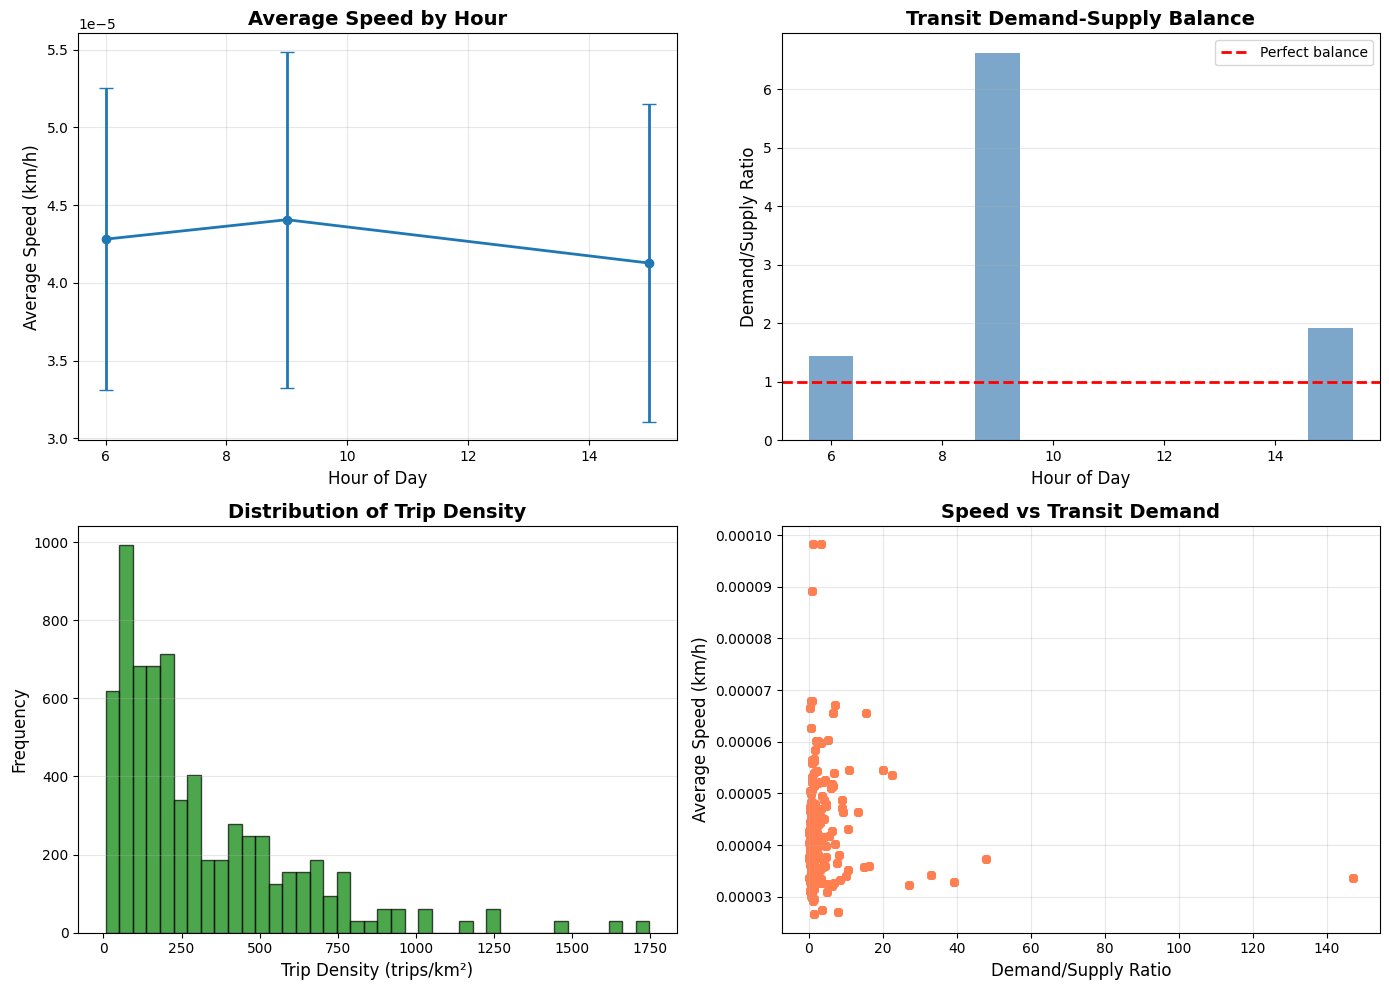

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Average speed by hour
speed_by_hour = ward_temporal_final_clean[
    ward_temporal_final_clean['avg_speed'] > 0
].groupby('hour')['avg_speed'].agg(['mean', 'std'])

axes[0, 0].errorbar(speed_by_hour.index, speed_by_hour['mean'], 
                    yerr=speed_by_hour['std'], marker='o', capsize=5, linewidth=2)
axes[0, 0].set_xlabel('Hour of Day', fontsize=12)
axes[0, 0].set_ylabel('Average Speed (km/h)', fontsize=12)
axes[0, 0].set_title('Average Speed by Hour', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Transit demand-supply balance
demand_supply = ward_temporal_final_clean.groupby('hour')['demand_supply_ratio'].mean()

axes[0, 1].bar(demand_supply.index, demand_supply.values, alpha=0.7, color='steelblue')
axes[0, 1].axhline(y=1, color='red', linestyle='--', linewidth=2, label='Perfect balance')
axes[0, 1].set_xlabel('Hour of Day', fontsize=12)
axes[0, 1].set_ylabel('Demand/Supply Ratio', fontsize=12)
axes[0, 1].set_title('Transit Demand-Supply Balance', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Trip density distribution
trip_density_nonzero = ward_temporal_final_clean[
    ward_temporal_final_clean['trip_density'] > 0
]['trip_density']

axes[1, 0].hist(trip_density_nonzero, bins=40, alpha=0.7, 
                color='green', edgecolor='black')
axes[1, 0].set_xlabel('Trip Density (trips/km²)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Distribution of Trip Density', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Speed vs Demand-Supply correlation
sample_data = ward_temporal_final_clean[
    (ward_temporal_final_clean['avg_speed'] > 0) & 
    (ward_temporal_final_clean['demand_supply_ratio'] > 0)
]

if len(sample_data) > 0:
    axes[1, 1].scatter(sample_data['demand_supply_ratio'], 
                       sample_data['avg_speed'],
                       alpha=0.4, s=30, color='coral')
    axes[1, 1].set_xlabel('Demand/Supply Ratio', fontsize=12)
    axes[1, 1].set_ylabel('Average Speed (km/h)', fontsize=12)
    axes[1, 1].set_title('Speed vs Transit Demand', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
output_plot = '/home/dataopske/Desktop/jav/data/plots/mobility_features_summary.png'
plt.savefig(output_plot, dpi=150, bbox_inches='tight')
print(f"\n✅ Summary plots saved to: {output_plot}")
plt.show()